# Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
import re
import string

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split, cross_validate, KFold
from sklearn.multiclass import OneVsRestClassifier
from scipy.sparse import hstack, csr_matrix

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, make_scorer, hamming_loss, ConfusionMatrixDisplay

In [2]:
# option to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 5000)

# Import Data

In [3]:
df = pd.read_csv('train.csv')

# Preprocessing

In [4]:
df['processed_text'] = df['comment_text'].apply(lambda x: re.sub(r'\n', ' ', str(x)))
df['processed_text'] = df['processed_text'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s.,!?;:()-]', '', str(x)))
df['processed_text'] = df['processed_text'].str.lower()
df['processed_text'] = df['processed_text'].apply(lambda x: contractions.fix(str(x)))
df['processed_text'] = df['processed_text'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))
df['tokens'] = df['processed_text'].apply(lambda x: nltk.word_tokenize(str(x)))
STOPWORDS = set(stopwords.words('english'))
df['tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in STOPWORDS])
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
df['processed_text'] = df['tokens'].apply(lambda x: re.sub(r'\s+', ' ', " ".join(x)).strip())

df['word_count'] = df['comment_text'].apply(lambda x: len(x.split())) 
df['unique_word_count'] = df['comment_text'].apply(lambda x: len(set(x.split())))
df['char_count'] = df['comment_text'].apply(lambda x: len(x))
df['upper_chars'] = df['comment_text'].apply(lambda x: sum([1 if char.isupper() else 0 for char in x]))
df['upper_words'] = df['comment_text'].apply(lambda x: sum([1 if word.isupper() else 0 for word in x.split()]))
df['punctuation_count'] = df['comment_text'].apply(lambda x: sum([1 if char in string.punctuation else 0 for char in x]))
df['biggest_word'] = df['comment_text'].apply(lambda x: len(max(x.split(), key=len)))
df['perc_punctuation'] = df['punctuation_count'] / (df['punctuation_count'] + df['char_count'])
df['perc_upper_chars'] = df['upper_chars'] / df['char_count']
df['perc_upper_words'] = df['upper_words'] / df['word_count']
df['avg_word_size'] = df['char_count'] / df['word_count']

In [5]:
df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,processed_text,tokens,word_count,unique_word_count,char_count,upper_chars,upper_words,punctuation_count,biggest_word,perc_punctuation,perc_upper_chars,perc_upper_words,avg_word_size
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,explanation edits made username hardcore metal...,"[explanation, edits, made, username, hardcore,...",43,41,264,17,2,10,16,0.036496,0.064394,0.046512,6.139535
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,daww match background colour seemingly stuck t...,"[daww, match, background, colour, seemingly, s...",17,17,112,8,1,12,10,0.096774,0.071429,0.058824,6.588235
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,hey man really trying edit war guy constantly ...,"[hey, man, really, trying, edit, war, guy, con...",42,39,233,4,0,6,11,0.025105,0.017167,0.000000,5.547619
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,make real suggestion improvement wondered sect...,"[make, real, suggestion, improvement, wondered...",113,82,622,11,5,21,44,0.032659,0.017685,0.044248,5.504425
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,sir hero chance remember page,"[sir, hero, chance, remember, page]",13,13,67,2,0,5,8,0.069444,0.029851,0.000000,5.153846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0,second time asking view completely contradicts...,"[second, time, asking, view, completely, contr...",47,44,295,2,0,18,13,0.057508,0.006780,0.000000,6.276596
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0,ashamed horrible thing put talk page 128611993,"[ashamed, horrible, thing, put, talk, page, 12...",18,18,99,2,0,4,12,0.038835,0.020202,0.000000,5.500000
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0,spitzer umm actual article prostitution ring c...,"[spitzer, umm, actual, article, prostitution, ...",12,12,81,4,0,4,12,0.047059,0.049383,0.000000,6.750000
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0,look like actually put speedy first version de...,"[look, like, actually, put, speedy, first, ver...",25,23,116,2,1,1,8,0.008547,0.017241,0.040000,4.640000


# Train Test Split

In [6]:
input_string = ['comment_text']

numerical_features = ['word_count', 'unique_word_count', 'char_count', 'upper_chars', 'upper_words', 'punctuation_count', 'biggest_word', 
            'perc_punctuation', 'perc_upper_chars', 'perc_upper_words', 'avg_word_size']

targets = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [7]:
# we need to add the processed_text to perform the bag of words and then we drop it
X = df[numerical_features + ['processed_text']]
y = df[targets]

comment_text_all = df[input_string]

In [8]:
X_train, X_test, y_train, y_test, text_train, text_test = train_test_split(X, y, comment_text_all, test_size=0.2, random_state=10)

# Bag of Words

In [9]:
# # using raw counts (bag of words) - Train - dense matrix
# vectorizer = CountVectorizer(max_features = 500, min_df = 5, max_df=0.9, ngram_range=(1,2))

# train_bag_of_words = vectorizer.fit_transform(X_train['processed_text'])
# train_bag_of_words_dense = train_bag_of_words.toarray()

# feature_names = vectorizer.get_feature_names_out()
# train_bag_of_words_df = pd.DataFrame(train_bag_of_words_dense, columns=feature_names, index=X_train.index)

# X_train = pd.concat([X_train.drop('processed_text', axis = 1), train_bag_of_words_df], axis=1)

In [10]:
# using raw counts (bag of words) - Train - sparse matrix
vectorizer = CountVectorizer(max_features = 2500, min_df = 5, max_df=0.9, ngram_range=(1,2))

train_bag_of_words_sparse = vectorizer.fit_transform(X_train['processed_text'])

feature_names = vectorizer.get_feature_names_out()

X_train_numerical_features_df = X_train.drop('processed_text', axis=1)
X_train_numerical_sparse = csr_matrix(X_train_numerical_features_df.values)
numerical_feature_names = X_train_numerical_features_df.columns.tolist()

X_train = hstack([X_train_numerical_sparse, train_bag_of_words_sparse])

In [11]:
# # using raw counts (bag of words) - Test - dense matrix
# test_bag_of_words = vectorizer.transform(X_test['processed_text'])
# test_bag_of_words_dense = test_bag_of_words.toarray()

# feature_names = vectorizer.get_feature_names_out()
# test_bag_of_words_df = pd.DataFrame(test_bag_of_words_dense, columns=feature_names, index=X_test.index)

# X_test = pd.concat([X_test.drop('processed_text', axis = 1), test_bag_of_words_df], axis=1)

In [12]:
# using raw counts (bag of words) - Test - sparse matrix
test_bag_of_words_sparse = vectorizer.transform(X_test['processed_text'])

X_test_numerical_features_df = X_test.drop('processed_text', axis=1)
X_test_numerical_sparse = csr_matrix(X_test_numerical_features_df.values)
numerical_feature_names = X_test_numerical_features_df.columns.tolist()

X_test = hstack([X_test_numerical_sparse, test_bag_of_words_sparse])

# Logistic Regression

In [13]:
base_classifier = LogisticRegression(random_state=42, solver='liblinear')
multi_label_model = OneVsRestClassifier(base_classifier, n_jobs=-1)

param_grid = {

}

f1_micro_scorer = make_scorer(f1_score, average='micro')

grid_search = GridSearchCV(
    estimator=multi_label_model,
    param_grid=param_grid,
    scoring=f1_micro_scorer, # Use your multi-label F1-score for optimization
    cv=5,
    verbose=2,             # Higher verbosity shows more progress
    n_jobs=-1,             # Parallelize grid search folds
    return_train_score=True # Useful for checking for overfitting
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=5,
             estimator=OneVsRestClassifier(estimator=LogisticRegression(random_state=42,
                                                                        solver='liblinear'),
                                           n_jobs=-1),
             n_jobs=-1, param_grid={}, return_train_score=True,
             scoring=make_scorer(f1_score, response_method='predict', average=micro),
             verbose=2)

In [14]:
print("\n--- Grid Search Results ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score (Micro F1): {grid_search.best_score_:.4f}")


--- Grid Search Results ---
Best parameters found: {}
Best cross-validation score (Micro F1): 0.1006


In [15]:
best_multi_label_model = grid_search.best_estimator_

In [16]:
y_pred_best = best_multi_label_model.predict(X_test)

print(f"Hamming Loss on test set: {hamming_loss(y_test, y_pred_best):.4f}")
print(f"Micro F1 on test set: {f1_score(y_test, y_pred_best, average='micro'):.4f}")

Hamming Loss on test set: 0.0323
Micro F1 on test set: 0.2206


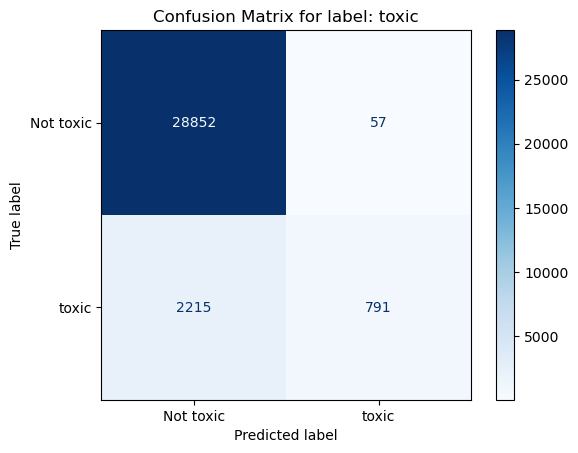

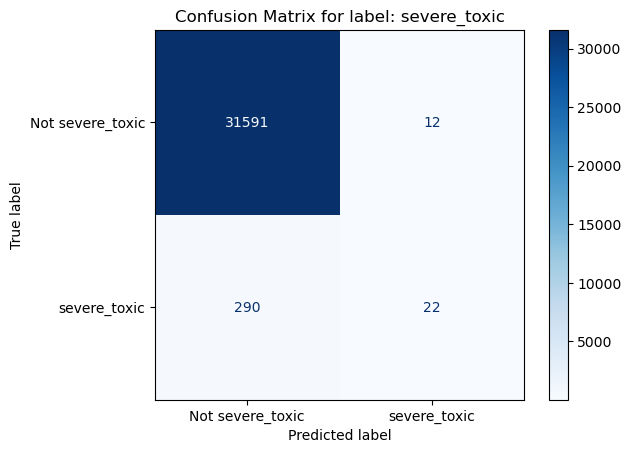

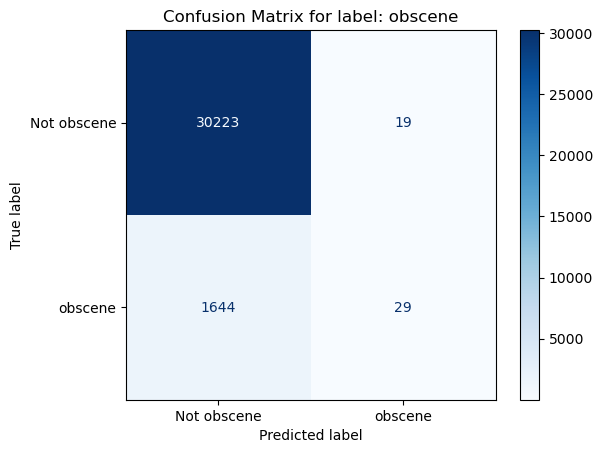

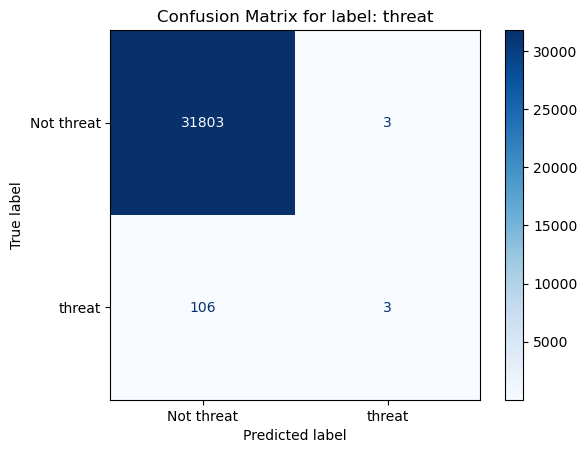

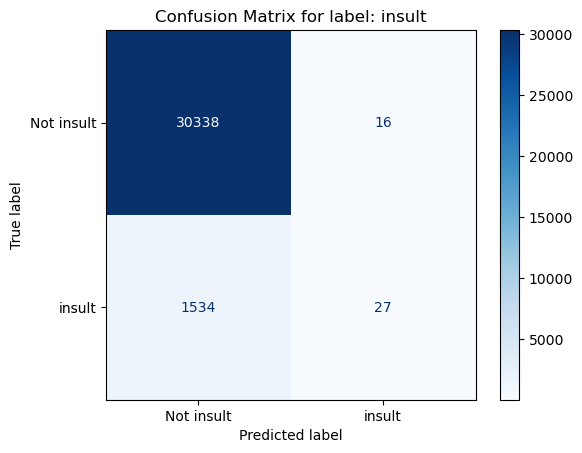

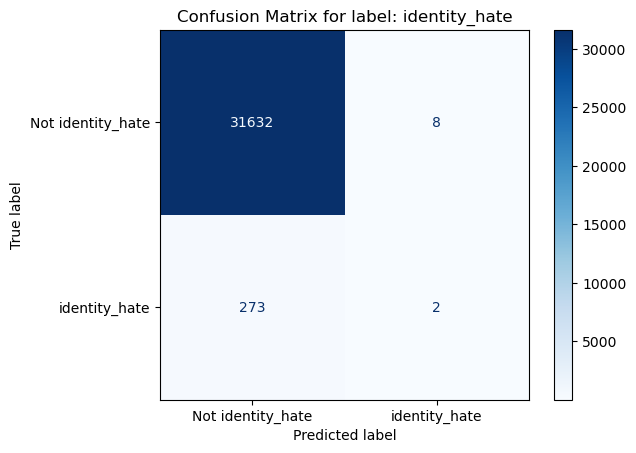

In [17]:
# Loop over each target (label) in the multi-label setting
for i, label in enumerate(targets):
    # Extract ground truth and predictions for this specific label
    y_true_label = y_test.iloc[:, i]
    y_pred_label = y_pred_best[:, i]

    # Compute the confusion matrix
    cm = confusion_matrix(y_true_label, y_pred_label)

    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Not {label}', label])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix for label: {label}')
    plt.show()

# Random Forest

In [18]:
base_classifier = RandomForestClassifier(random_state=42)
multi_label_model = OneVsRestClassifier(base_classifier, n_jobs=-1)

# empty grid just to create a simple training test to check the time required to fit the model
param_grid = {

}

f1_micro_scorer = make_scorer(f1_score, average='micro')

grid_search = GridSearchCV(
    estimator=multi_label_model,
    param_grid=param_grid,
    scoring=f1_micro_scorer, # Use your multi-label F1-score for optimization
    cv=5,
    verbose=2,             # Higher verbosity shows more progress
    n_jobs=-1,             # Parallelize grid search folds
    return_train_score=True # Useful for checking for overfitting
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=5,
             estimator=OneVsRestClassifier(estimator=RandomForestClassifier(random_state=42),
                                           n_jobs=-1),
             n_jobs=-1, param_grid={}, return_train_score=True,
             scoring=make_scorer(f1_score, response_method='predict', average=micro),
             verbose=2)

In [19]:
print("\n--- Grid Search Results ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score (Micro F1): {grid_search.best_score_:.4f}")


--- Grid Search Results ---
Best parameters found: {}
Best cross-validation score (Micro F1): 0.6524


In [20]:
best_multi_label_model = grid_search.best_estimator_

In [21]:
y_pred_best = best_multi_label_model.predict(X_test)

print(f"Hamming Loss on test set: {hamming_loss(y_test, y_pred_best):.4f}")
print(f"Micro F1 on test set: {f1_score(y_test, y_pred_best, average='micro'):.4f}")

Hamming Loss on test set: 0.0203
Micro F1 on test set: 0.6591


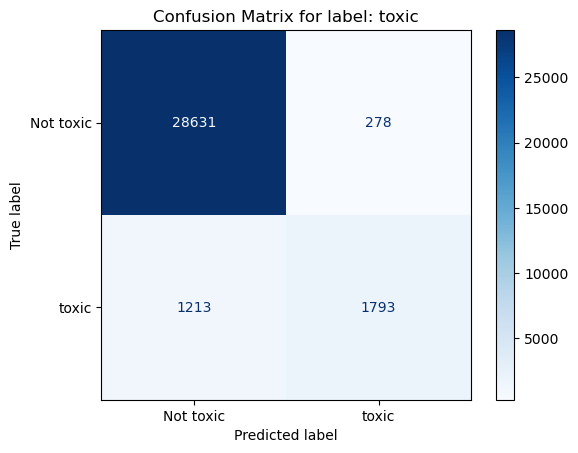

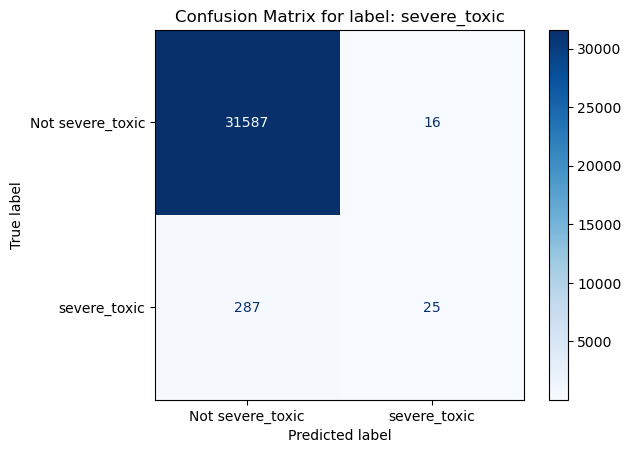

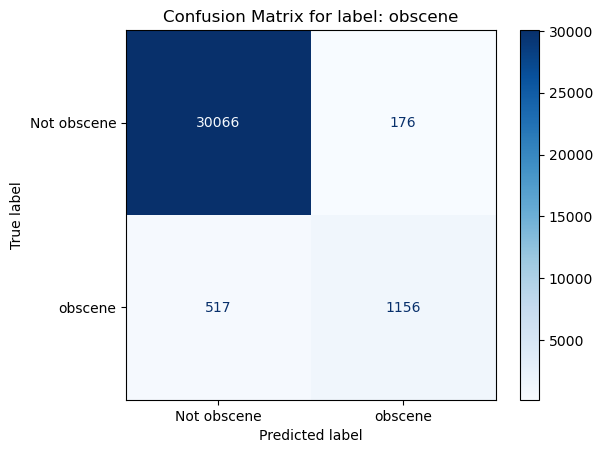

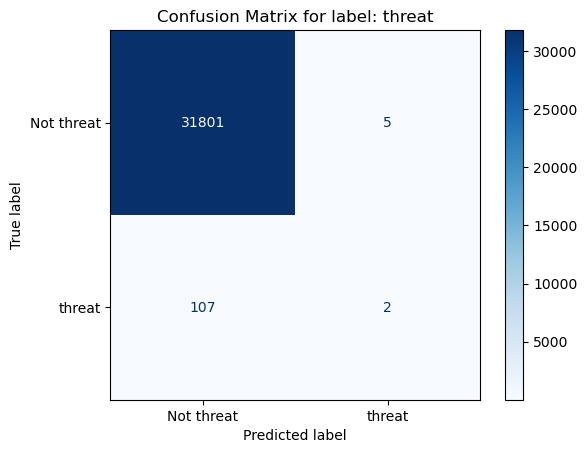

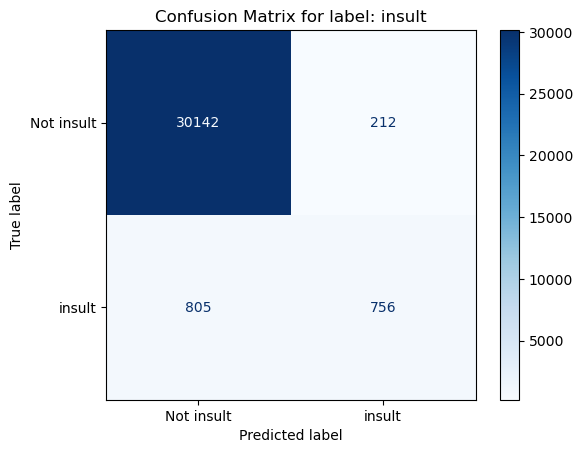

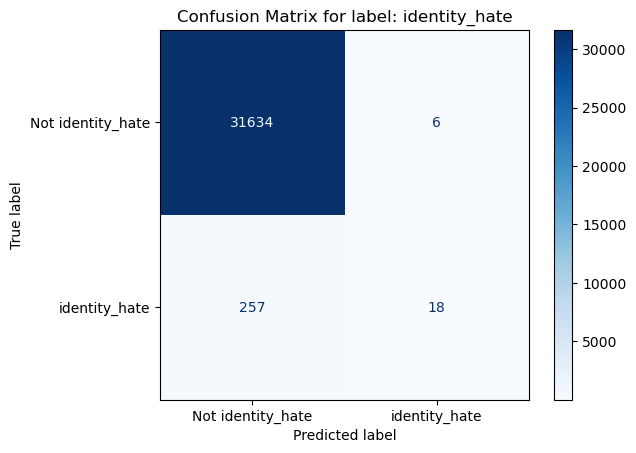

In [22]:
# Loop over each target (label) in the multi-label setting
for i, label in enumerate(targets):
    # Extract ground truth and predictions for this specific label
    y_true_label = y_test.iloc[:, i]
    y_pred_label = y_pred_best[:, i]

    # Compute the confusion matrix
    cm = confusion_matrix(y_true_label, y_pred_label)

    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Not {label}', label])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix for label: {label}')
    plt.show()

In [23]:
all_feature_names = numerical_feature_names + list(vectorizer.get_feature_names_out())

estimators = best_multi_label_model.estimators_

for i, (label, estimator) in enumerate(zip(targets, estimators)):
    importances = estimator.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    print(f"\nTop Features for Label: {label}")
    print(importance_df.head(10))  # Top 10 features


Top Features for Label: toxic
               Feature  Importance
949               fuck    0.065082
956            fucking    0.037696
8     perc_upper_chars    0.030256
2012              shit    0.026132
9     perc_upper_words    0.024650
2           char_count    0.021528
10       avg_word_size    0.020255
7     perc_punctuation    0.019610
3          upper_chars    0.019177
2152              suck    0.019112

Top Features for Label: severe_toxic
               Feature  Importance
949               fuck    0.058047
2           char_count    0.040218
8     perc_upper_chars    0.039326
10       avg_word_size    0.038514
7     perc_punctuation    0.033806
0           word_count    0.033151
1    unique_word_count    0.032606
3          upper_chars    0.032439
6         biggest_word    0.029197
956            fucking    0.027838

Top Features for Label: obscene
               Feature  Importance
949               fuck    0.123108
956            fucking    0.069248
2012              shit 

# XGBoost

In [25]:
base_classifier = XGBClassifier(objective='binary:logistic', eval_metric='mlogloss', random_state=42)
multi_label_model = OneVsRestClassifier(base_classifier, n_jobs=-1)

# empty grid just to create a simple training test to check the time required to fit the model
param_grid = {
    'estimator__n_estimators': [50, 200],
    'estimator__max_depth': [6, 20],
}

f1_micro_scorer = make_scorer(f1_score, average='micro')

grid_search = GridSearchCV(
    estimator=multi_label_model,
    param_grid=param_grid,
    scoring=f1_micro_scorer, # Use your multi-label F1-score for optimization
    cv=5,
    verbose=2,             # Higher verbosity shows more progress
    n_jobs=-1,             # Parallelize grid search folds
    return_train_score=True # Useful for checking for overfitting
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5,
             estimator=OneVsRestClassifier(estimator=XGBClassifier(base_score=None,
                                                                   booster=None,
                                                                   callbacks=None,
                                                                   colsample_bylevel=None,
                                                                   colsample_bynode=None,
                                                                   colsample_bytree=None,
                                                                   device=None,
                                                                   early_stopping_rounds=None,
                                                                   enable_categorical=False,
                                                                   eval_metric='mlogloss',
                                                                   feature_types=None,
                                                                   feature_weights=None,
                                                                   gamma=None,
                                                                   grow_policy=None,
                                                                   importance_t...
                                                                   max_leaves=None,
                                                                   min_child_weight=None,
                                                                   missing=nan,
                                                                   monotone_constraints=None,
                                                                   multi_strategy=None,
                                                                   n_estimators=None,
                                                                   n_jobs=None,
                                                                   num_parallel_tree=None, ...),
                                           n_jobs=-1),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [6, 20],
                         'estimator__n_estimators': [50, 200]},
             return_train_score=True,
             scoring=make_scorer(f1_score, response_method='predict', average=micro),
             verbose=2)

In [26]:
print("\n--- Grid Search Results ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score (Micro F1): {grid_search.best_score_:.4f}")


--- Grid Search Results ---
Best parameters found: {'estimator__max_depth': 6, 'estimator__n_estimators': 200}
Best cross-validation score (Micro F1): 0.6843


In [27]:
best_multi_label_model = grid_search.best_estimator_

In [28]:
y_pred_best = best_multi_label_model.predict(X_test)

print(f"Hamming Loss on test set: {hamming_loss(y_test, y_pred_best):.4f}")
print(f"Micro F1 on test set: {f1_score(y_test, y_pred_best, average='micro'):.4f}")

Hamming Loss on test set: 0.0198
Micro F1 on test set: 0.6864


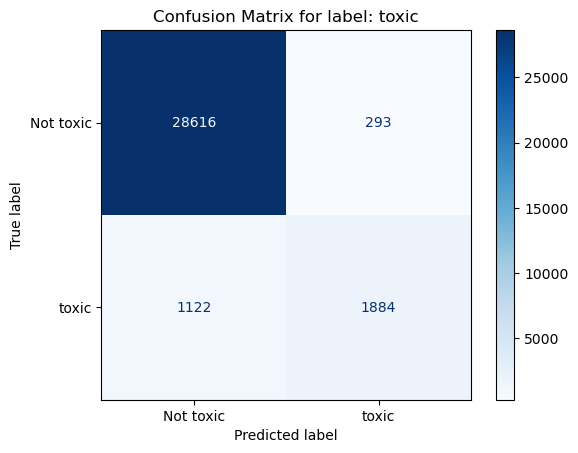

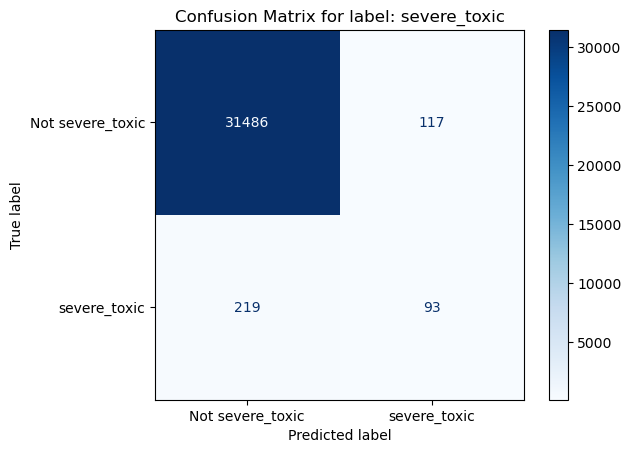

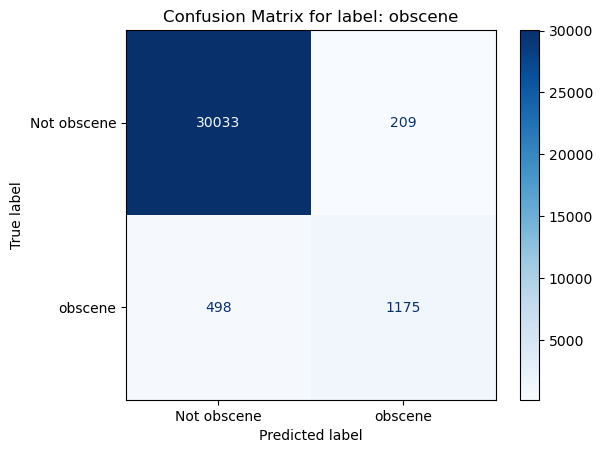

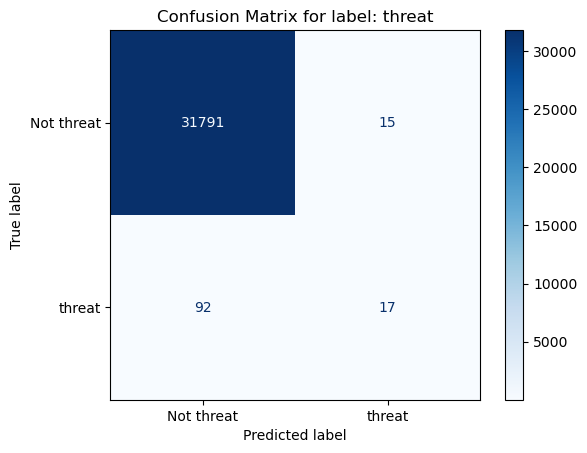

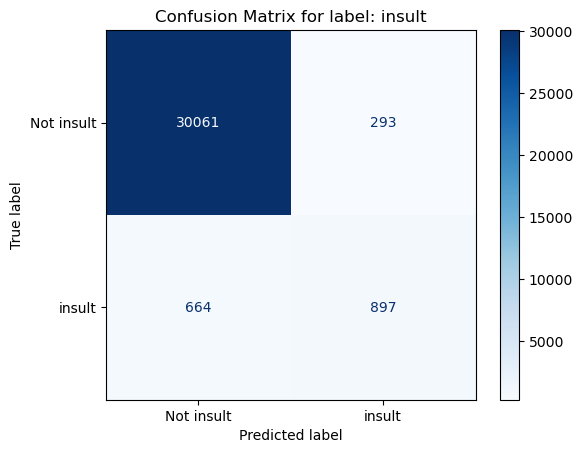

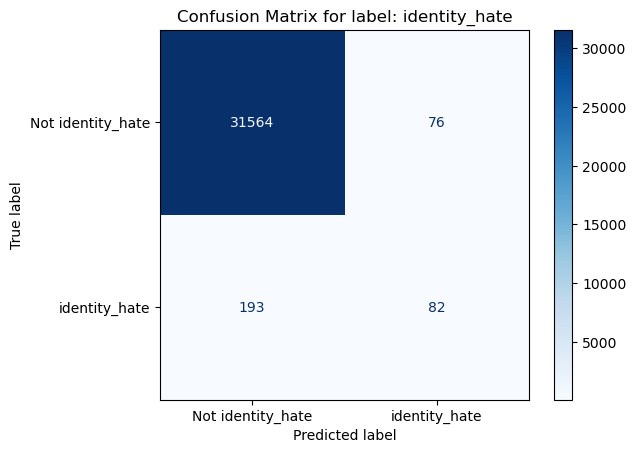

In [29]:
# Loop over each target (label) in the multi-label setting
for i, label in enumerate(targets):
    # Extract ground truth and predictions for this specific label
    y_true_label = y_test.iloc[:, i]
    y_pred_label = y_pred_best[:, i]

    # Compute the confusion matrix
    cm = confusion_matrix(y_true_label, y_pred_label)

    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Not {label}', label])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix for label: {label}')
    plt.show()

In [30]:
all_feature_names = numerical_feature_names + list(vectorizer.get_feature_names_out())

estimators = best_multi_label_model.estimators_

for i, (label, estimator) in enumerate(zip(targets, estimators)):
    importances = estimator.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    print(f"\nTop Features for Label: {label}")
    print(importance_df.head(10))  # Top 10 features


Top Features for Label: toxic
      Feature  Importance
949      fuck    0.044254
956   fucking    0.031685
2152     suck    0.028932
2012     shit    0.021145
217        as    0.016995
230   asshole    0.016795
1104    idiot    0.015161
2142   stupid    0.012746
316     bitch    0.011680
969       gay    0.010768

Top Features for Label: severe_toxic
               Feature  Importance
4          upper_words    0.400933
9     perc_upper_words    0.116775
949               fuck    0.045102
1873            remove    0.024868
956            fucking    0.022781
136               also    0.021747
2152              suck    0.012883
951          fuck fuck    0.012131
316              bitch    0.006993
8     perc_upper_chars    0.006489

Top Features for Label: obscene
      Feature  Importance
949      fuck    0.091135
316     bitch    0.088383
956   fucking    0.083508
2152     suck    0.077886
2012     shit    0.025533
217        as    0.024044
230   asshole    0.019648
842    faggot    0.

# Notes

The results are way better when using the bag of words features. And they keep increasing as I add more features until 2.5k. Due to memory issues I couldn't add more features

| Model    | Approach | Micro F1 | Hamming Loss |
| -------- | ------- | ------- | ------- |
| LogReg  | Baseline    | 0.0894 | 0.0354 |
| LogReg  | BagOfWords 500 features   | 0.3395 | 0.0303 |
| LogReg  | BagOfWords 1k features   | 0.4903 | 0.0264 |
| LogReg  | BagOfWords 2.5k features   | 0.2206 | 0.0323 |
| -------- | ------- | ------- | ------- |
| RandomForest  | Baseline    | 0.1547 | 0.0377 |
| RandomForest  | BagOfWords 500 features   | 0.5713 | 0.0238 |
| RandomForest  | BagOfWords 1k features   | 0.6505 | 0.0208 |
| RandomForest  | BagOfWords 2.5k features   | 0.6591 | 0.0203 |
| -------- | ------- | ------- | ------- |
| XGBoost  | Baseline    | 0.1347 | 0.0361 |
| XGBoost  | BagOfWords 500 features   | 0.5906 | 0.0235 | 
| XGBoost  | BagOfWords 1k features   | 0.6686 | 0.0205 |
| XGBoost  | BagOfWords 2.5k features   | 0.6864 | 0.0198 |

The next approach will be using TF-IDF instead of Bag of Words 